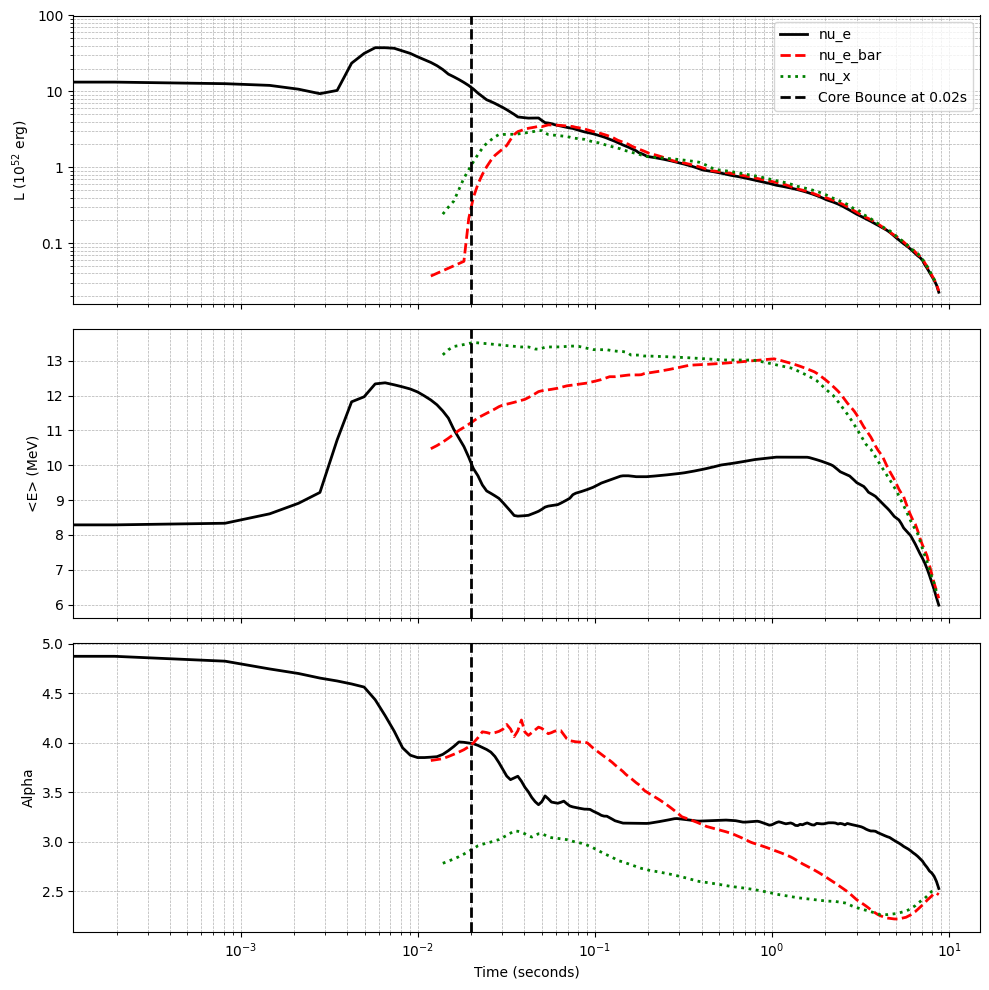

In [164]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import pandas as pd
import matplotlib.colors as mcolors

# Define directories
base_directory = "/Users/jacob/Downloads/garching"
data_directory = os.path.join(base_directory, "garching_fluxes_log")

# Define file paths
file_pattern = os.path.join(data_directory, "pinched_*.dat")  
info_key_file = os.path.join(base_directory, "garching_pinched_info_key.dat")
info_file = os.path.join(base_directory, "garching_pinched_info.dat")

# Load data
info_key_data = np.loadtxt(info_key_file)  # First column: IDs, Second column: time values
info_data = np.loadtxt(info_file)  # First column: IDs, remaining columns: physics data

# Create mapping from ID to time using info_key_data
id_to_time = {int(row[0]): (row[1], row[2]) for row in info_key_data}

# Create mappings for alpha, energy, and luminosity using info_data
id_to_alpha = {int(row[0]): (row[1], row[2], row[3]) for row in info_data}  # Alpha values (nu_e, nu_e_bar, nu_x)
id_to_energy = {int(row[0]): (row[4], row[5], row[6]) for row in info_data}  # Energy values (nu_e, nu_e_bar, nu_x)
id_to_luminosity = {int(row[0]): (row[7], row[8], row[9]) for row in info_data}  # Luminosity values (nu_e, nu_e_bar, nu_x)

# Get list of pinched files
file_list = sorted(glob.glob(file_pattern))  # No need to extract numbers from filenames

# Store data
time_values = []
alpha_values, energy_values, luminosity_values = {}, {}, {}
species_list = ["nu_e", "nu_e_bar", "nu_x"]
for species in species_list:
    alpha_values[species] = []
    energy_values[species] = []
    luminosity_values[species] = []

# Process data based on direct ID matching
for row in info_key_data:
    file_id = int(row[0])  # First column of garching_pinched_info_key.dat
    time_bin = row[1]   # Second column (time value)
    dt = row[2]

    if file_id in id_to_alpha and file_id in id_to_energy and file_id in id_to_luminosity:
        alpha_vals = id_to_alpha[file_id]
        energy_vals = id_to_energy[file_id]
        luminosity_vals = id_to_luminosity[file_id]

        # Append valid data
        time_values.append(time_bin)
        for i, species in enumerate(species_list):
            alpha_values[species].append(alpha_vals[i] if alpha_vals[i] != 0 else np.nan)
            energy_values[species].append(energy_vals[i] if energy_vals[i] != 0 else np.nan)
            luminosity_values[species].append(luminosity_vals[i] if luminosity_vals[i] != 0 else np.nan)

# Convert to arrays
time_values = np.array(time_values) 
for species in species_list:
    alpha_values[species] = np.array(alpha_values[species], dtype=float)
    energy_values[species] = np.array(energy_values[species], dtype=float)
    luminosity_values[species] = np.array(luminosity_values[species], dtype=float) / 1e52  # Corrected: use 1e48

# Correct division for luminosity_values by dt
for idx, species in enumerate(species_list):
    luminosity_values[species] = np.array(luminosity_values[species]) / np.array([row[2] for row in info_key_data])  # Divide by dt values (row[2] for each time_bin)

# Define species styles
colors = {"nu_e": "black", "nu_e_bar": "red", "nu_x": "green"}
linestyles = {"nu_e": "-", "nu_e_bar": "--", "nu_x": ":"}

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Function for plotting
def plot_data(ax, y_values, ylabel, log_y=False):
    for species in species_list:
        valid_mask = ~np.isnan(y_values[species])  # Ignore NaNs
        ax.plot(time_values[valid_mask], np.array(y_values[species])[valid_mask],
                linestyle=linestyles[species], color=colors[species], linewidth=2, label=species)
    ax.set_yscale('log' if log_y else 'linear')
    ax.axvline(x=0.02, color='k', linestyle='--', linewidth=2, label="Core Bounce at 0.02s")  # Vertical line at 0.02s
    ax.set_ylabel(ylabel)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)

# Plot Luminosity
plot_data(axes[0], luminosity_values, r"L ($10^{52}$ erg)", log_y=True)
axes[0].set_yticks([0.1, 1, 10, 100])  # Adjusted for better readability
axes[0].set_yticklabels(["0.1", "1", "10", "100"]) 

# Plot Energy
plot_data(axes[1], energy_values, r"<E> (MeV)")

# Plot Alpha
plot_data(axes[2], alpha_values, r"Alpha")

# Set log scale for time
axes[-1].set_xscale('log')
axes[-1].set_xlabel("Time (seconds)")

# Add legend
axes[0].legend(loc="best")

plt.tight_layout()
plt.show()

In [183]:
# Get sorted list of pinched files
file_list = sorted(glob.glob(file_pattern), key=lambda x: int(x.split("_")[-1].split(".")[0]))


# Storage for heatmap data
energy_values_k = []
time_values_k = []
counts_values_k = []
delta_t_values_k= []
max_counts_values = []
del_t_values_k = []
t_values_k = []

# Process each pinched file
for file in file_list:
    file_id = int(file.split("_")[-1].split(".")[0])  # Extract ID from filename
    if file_id in id_to_time:
        time_bin, bin_width = id_to_time[file_id]  # Get time and bin width
        data = np.loadtxt(file)
        filtered_data = data[::1]  # Skip every other line
        
        energy = filtered_data[:, 0] * 1000  # Energy in MeV
        counts = filtered_data[:, 1]  # Counts
        max_count = np.max(counts)
        
        # Store values
        energy_values_k.extend(energy)
        time_values_k.extend([time_bin] * len(counts))
        counts_values_k.extend(counts)
        delta_t_values_k.extend([bin_width] * len(counts))  # Store bin width
        max_counts_values.append(max_count)
        del_t_values_k.append(bin_width)
        t_values_k.append(time_bin)

max_counts_values = np.array(max_counts_values)
      
# Create DataFrame
df_k = pd.DataFrame({
    "Time (s)": time_values_k, 
    "Energy (MeV)": energy_values_k, 
    "Counts": counts_values_k, 
    "Delta T": delta_t_values_k
})

print("Data loading is done!")



Data loading is done!


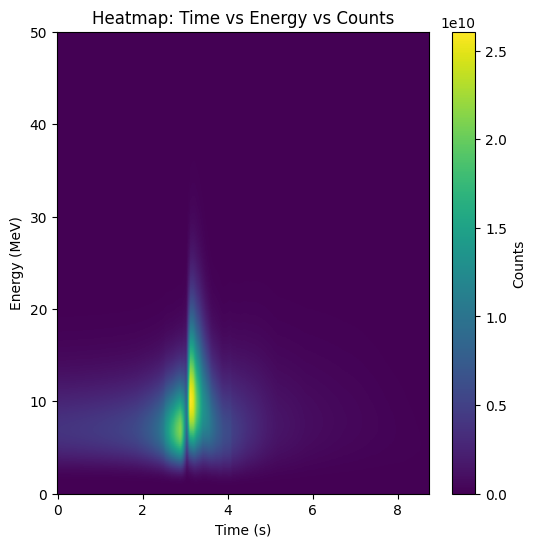

In [184]:
df_k["Counts"] = df_k["Counts"] / df_k["Delta T"]

# Create pivot table for heatmap: Sum counts per energy/time bin
heatmap_data = df_k.pivot_table(index="Energy (MeV)", columns="Time (s)", values="Counts", aggfunc="sum")

# Calculate time edges for extent (no need to use Delta T)
time_edges = np.array(sorted(df_k["Time (s)"].unique()))

# Plot heatmap (Energy on Y-axis, Time on X-axis)
plt.figure(figsize=(6, 6))
plt.imshow(
    heatmap_data, 
    aspect="auto", 
    origin="lower",  
    extent=[time_edges.min(), time_edges.max(), df_k["Energy (MeV)"].min(), df_k["Energy (MeV)"].max()]
)

plt.colorbar(label="Counts")
plt.xlabel("Time (s)")
plt.ylabel("Energy (MeV)")
plt.title("Heatmap: Time vs Energy vs Counts")
plt.ylim(top=50)  # Limit Y-axis to energy range
#plt.xlim(left = -0.2, right = 0.8 )
plt.show()

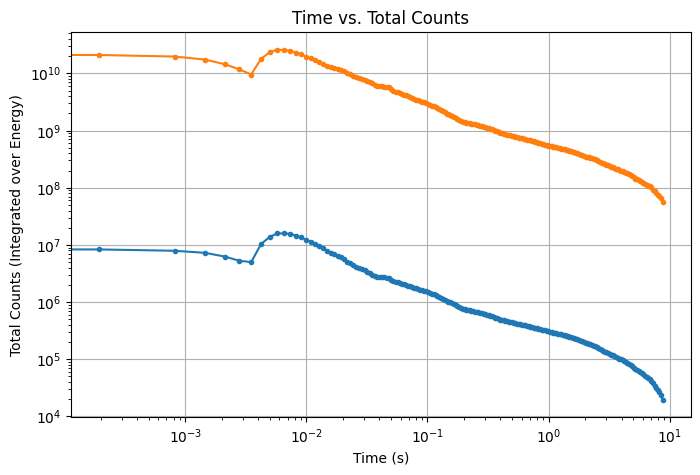

In [185]:
# Integrate over Energy: Sum counts for each Time bin
time_integrated_counts = heatmap_data.sum(axis=0)  # Sum along energy axis

# Plot Time vs. Integrated Counts
plt.figure(figsize=(8, 5))
plt.plot(time_integrated_counts.index, time_integrated_counts.values * 1e-5  , marker='.', linestyle='-')
plt.plot(t_values_k, max_counts_values/del_t_values_k, marker='.', linestyle='-')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Time (s)")
plt.ylabel("Total Counts (Integrated over Energy)")
plt.title("Time vs. Total Counts")
#plt.xlim(left= 10E-3 , right= 10E0)
plt.grid(True)
plt.show()

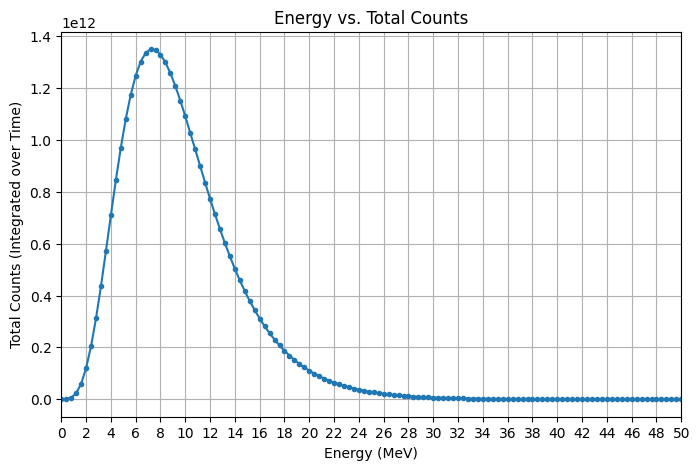

In [121]:
# Integrate over Time: Sum counts for each Energy bin
energy_integrated_counts = heatmap_data.sum(axis=1)  # Sum along time axis
# Plot Energy vs. Integrated Counts
plt.figure(figsize=(8, 5))
plt.plot(energy_integrated_counts.index, energy_integrated_counts.values, marker='.', linestyle='-')
plt.xlabel("Energy (MeV)")
plt.ylabel("Total Counts (Integrated over Time)")
plt.xticks(np.arange(0, 52, 2))  
plt.title("Energy vs. Total Counts")
plt.xlim(left= 0 , right= 50)
plt.grid(True)
plt.show()